# ¿Cómo podemos lograr predecir el precio?

In [14]:
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

### Carga de csv

In [8]:
df_applications = pd.read_csv("./data-cleaned/applications.csv")
df_categories = pd.read_csv("./data-cleaned/categories_clean.csv")
df_developers = pd.read_csv("./data/developers.csv")
df_genres = pd.read_csv("./data-cleaned/genres_clean.csv")
df_platforms = pd.read_csv("./data/platforms.csv")
df_publishers = pd.read_csv("./data/publishers.csv")
df_reviews = pd.read_csv("./data/reviews.csv")
df_application_categories = pd.read_csv("./data/application_categories.csv")
df_application_developers = pd.read_csv("./data/application_developers.csv")
df_application_genres = pd.read_csv("./data/application_genres.csv")
df_application_platforms = pd.read_csv("./data/application_platforms.csv")
df_application_publishers = pd.read_csv("./data/application_publishers.csv")

In [9]:
def _safe_convert_age(x) -> int:
    if pd.isna(x): return 0
    s = str(x)
    if "17+" in s: return 17
    try:
        return int(float(s)) if s != '120' else 12
    except ValueError:
        return 0
df_applications.required_age = df_applications['required_age'].apply(_safe_convert_age)

,appid,metacritic_score,recommendations_total,mat_initial_price,mat_final_price,mat_discount_percent,mat_achievement_count
count,2.040710e+05,4426.000000,2.241500e+04,1.372520e+05,1.372520e+05,137252.000000,59809.000000
mean,1.991415e+06,74.017849,4.675253e+03,2.336376e+04,2.125079e+04,5.354334,35.080439
std,1.055149e+06,10.277721,4.657130e+04,8.772064e+05,7.971281e+05,17.843623,200.504834
min,1.000000e+01,6.000000,1.010000e+02,5.000000e+01,4.400000e+01,0.000000,0.000000
25%,1.097985e+06,68.000000,1.750000e+02,2.990000e+02,2.990000e+02,0.000000,10.000000
50%,1.937360e+06,76.000000,3.710000e+02,4.990000e+02,4.990000e+02,0.000000,18.000000
75%,2.878555e+06,81.000000,1.216000e+03,9.990000e+02,9.990000e+02,0.000000,32.000000
max,3.990870e+06,97.000000,4.661011e+06,8.990000e+07,8.910000e+07,95.000000,9821.000000


In [10]:
df_applications.head()

,appid,name,type,is_free,release_date,short_description,supported_languages,metacritic_score,recommendations_total,mat_supports_windows,...,mat_pc_os_min,mat_pc_processor_min,mat_pc_memory_min,mat_pc_graphics_min,mat_pc_os_rec,mat_pc_processor_rec,mat_pc_memory_rec,mat_pc_graphics_rec,created_at,updated_at
0,10,Counter-Strike,game,False,2000-11-01,Play the world's number 1 online action game. ...,"English<strong>*</strong>, French<strong>*</st...",88.0,161854.0,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-09-07 16:27:12.218587+00:00,2025-09-29 02:01:37.107239+00:00
1,20,Team Fortress Classic,game,False,1999-04-01,One of the most popular online action games of...,"English, French, German, Italian, Spanish - Sp...",NaN,6633.0,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-09-07 16:27:12.218587+00:00,2025-09-29 02:01:37.107239+00:00
2,30,Day of Defeat,game,False,2003-05-01,Enlist in an intense brand of Axis vs. Allied ...,"English, French, German, Italian, Spanish - Spain",79.0,4308.0,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-09-07 16:27:12.218587+00:00,2025-09-29 02:01:37.107239+00:00
3,40,Deathmatch Classic,game,False,2001-06-01,Enjoy fast-paced multiplayer gaming with Death...,"English, French, German, Italian, Spanish - Sp...",NaN,2338.0,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-09-07 16:27:12.218587+00:00,2025-09-29 02:01:37.107239+00:00
4,50,Half-Life: Opposing Force,game,False,1999-11-01,Return to the Black Mesa Research Facility as ...,"English, French, German, Korean",NaN,22793.0,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-09-07 16:27:12.218587+00:00,2025-09-29 02:01:37.107239+00:00


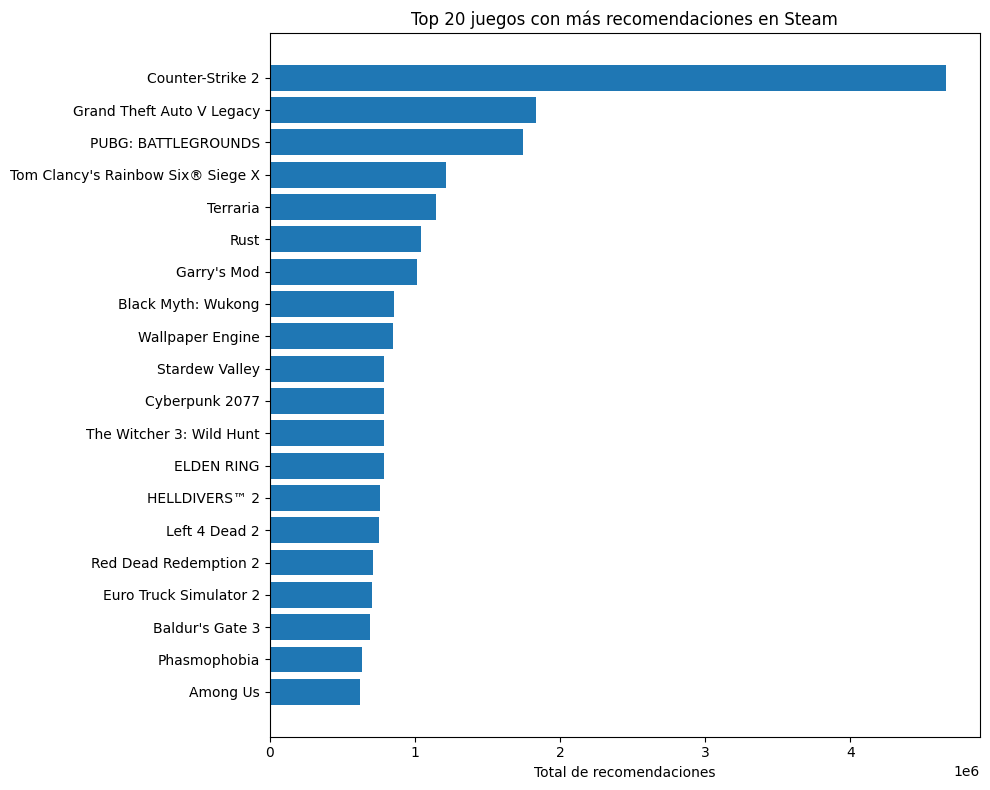

In [ ]:
top20 = df_applications.sort_values('recommendations_total', ascending=False).head(20)[['name', 'recommendations_total']]

plt.figure(figsize=(10, 8))
plt.barh(top20['name'], top20['recommendations_total'])
plt.xlabel('Total de recomendaciones')
plt.title('Top 20 juegos con más recomendaciones en Steam')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

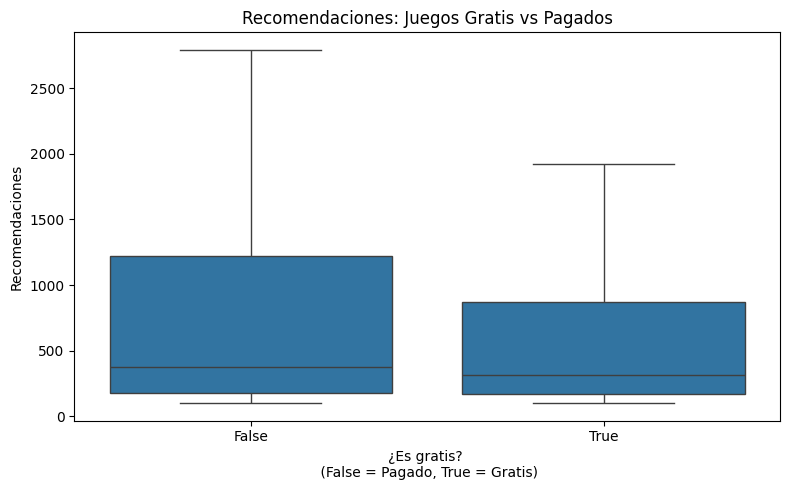

In [17]:
con_recs = df_applications[df_applications['recommendations_total'] > 0].copy()

plt.figure(figsize=(8, 5))
sns.boxplot(data=con_recs, x='is_free', y='recommendations_total', showfliers=False)
plt.xlabel('¿Es gratis? \n (False = Pagado, True = Gratis)')
plt.ylabel('Recomendaciones')
plt.title('Recomendaciones: Juegos Gratis vs Pagados')
plt.tight_layout()
plt.show()

Filtra solo juegos que tienen al menos 1 recomendación.
El grafico nos dice lo siguiente:

* Las medianas son casi iguales, el juego tipico gratis y pagado tienen el mismo exito.
* Las cajas si tienen un ligera diferencia. Entre los juegos pagados hay mas dispersion, es decir, algunos logran mas exito que el promedio.
* is_free no es suficiente para determinar el exito de un juego.
* los juegos pagados tienen mas variabilidad, hay pagados exitosos y algunos que fracasan. Algo mas determina quien triunfa y quien gana.

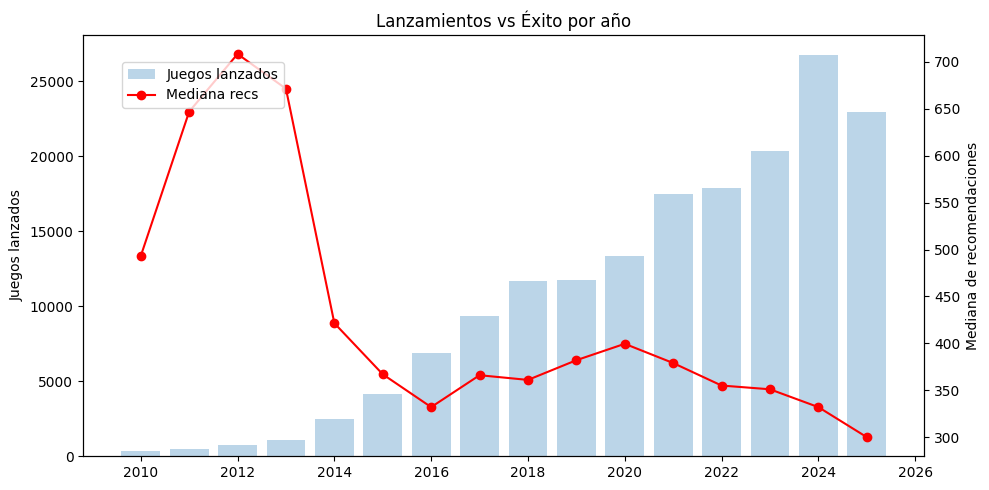

In [19]:
df_temp = df_applications.copy()
df_temp['release_date'] = pd.to_datetime(df_temp['release_date'], errors='coerce')
df_temp['year'] = df_temp['release_date'].dt.year
df_temp = df_temp[(df_temp['year'] >= 2010) & (df_temp['year'] <= 2025)]

por_año = df_temp.groupby('year').agg(
    juegos=('appid', 'count'),
    mediana_recs=('recommendations_total', 'median')
).dropna()

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.bar(por_año.index, por_año['juegos'], alpha=0.3, label='Juegos lanzados')
ax1.set_ylabel('Juegos lanzados')

ax2 = ax1.twinx()
ax2.plot(por_año.index, por_año['mediana_recs'], color='red', marker='o', label='Mediana recs')
ax2.set_ylabel('Mediana de recomendaciones')

plt.title('Lanzamientos vs Éxito por año')
fig.legend(loc='upper left', bbox_to_anchor=(0.12, 0.88))
plt.tight_layout()
plt.show()

Es el efecto de saturación del mercado. Antes de 2014, se publicaban pocos juegos en Steam (había filtro de calidad), entonces cada juego recibía más atención y más reseñas. A partir de 2014 Steam abrió las puertas con Greenlight y luego Steam Direct, entraron miles de juegos al año, y la atención del jugador se diluyó. Hoy un juego "típico" recibe la mitad de recomendaciones que uno de 2012, simplemente porque compite con 25.000 otros lanzamientos ese mismo año.

IA:
Puedes escribir en el informe algo como: "La mediana de recomendaciones ha caído un 57% entre 2012 y 2025, a pesar de que el número de lanzamientos creció 30x. Esto evidencia que el año de lanzamiento es una variable relevante para predecir éxito, ya que los juegos recientes enfrentan mayor competencia por la atención del jugador. Esto refuerza la necesidad de un modelo multivariable que identifique qué otros factores permiten a un juego destacar en un mercado cada vez más saturado."